# Stage 4 — Autoencoder (Deep Dimensionality Reduction)
### Cancer Prediction from Gene Expression Data — Prediction Track

This notebook loads the feature-selected data from `02_feature_selection.ipynb` (~300 genes) and trains an
Autoencoder to compress it into a **64-dimensional patient fingerprint**. Only the trained Encoder half is
kept afterward — the Decoder is discarded once training is done, since its only job was to force the
bottleneck layer to learn a good compressed representation.

**Architecture:**

| Layer | Size |
|---|---|
| Input | ~300 (number of selected genes) |
| Encoder Layer 1 | 256, ReLU |
| Encoder Layer 2 | 128, ReLU |
| **Bottleneck** | **64** (the compressed fingerprint) |
| Decoder Layer 1 | 128, ReLU |
| Decoder Layer 2 | 256, ReLU |
| Output | same size as input |

Training goal: minimize reconstruction error (Mean Squared Error) between input and output — this forces
the 64-dim bottleneck to retain the most essential gene expression patterns.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import joblib
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Gene Project/processed_data"
MODEL_DIR = "/content/drive/MyDrive/Gene Project/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("GPU available:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Feature-Selected Data

In [2]:
X_train = pd.read_csv(f"{DATA_DIR}/X_train_selected.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test_selected.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").iloc[:, 0].values
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").iloc[:, 0].values
selected_genes = joblib.load(f"{DATA_DIR}/selected_genes.pkl")
label_mapping = joblib.load(f"{DATA_DIR}/label_mapping.pkl")

N_GENES = X_train.shape[1]

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Number of input genes to the Autoencoder:", N_GENES)
print("Label mapping:", label_mapping)

X_train: (860, 300)  X_test: (117, 300)
Number of input genes to the Autoencoder: 300
Label mapping: {0: 'normal', 1: 'tumor'}


## 2. Build the Autoencoder
Note: the Autoencoder is **unsupervised** — it only ever sees `X` (gene expression), never `y` (the
tumor/normal label). Its job is purely to learn a compact representation of the gene expression patterns
themselves; the label is only used later, by the CNN and XGBoost classifiers.

In [3]:
def build_autoencoder(input_dim, bottleneck_dim=64):
    # --- Encoder ---
    encoder_input = keras.Input(shape=(input_dim,), name="encoder_input")
    x = layers.Dense(256, activation="relu")(encoder_input)
    x = layers.Dense(128, activation="relu")(x)
    bottleneck = layers.Dense(bottleneck_dim, activation="relu", name="bottleneck")(x)

    encoder = keras.Model(encoder_input, bottleneck, name="encoder")

    # --- Decoder ---
    decoder_input = keras.Input(shape=(bottleneck_dim,), name="decoder_input")
    x = layers.Dense(128, activation="relu")(decoder_input)
    x = layers.Dense(256, activation="relu")(x)
    decoder_output = layers.Dense(input_dim, activation="linear")(x)

    decoder = keras.Model(decoder_input, decoder_output, name="decoder")

    # --- Full Autoencoder (Encoder -> Decoder) ---
    autoencoder_input = keras.Input(shape=(input_dim,), name="autoencoder_input")
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    autoencoder = keras.Model(autoencoder_input, decoded, name="autoencoder")

    return autoencoder, encoder, decoder


autoencoder, encoder, decoder = build_autoencoder(input_dim=N_GENES, bottleneck_dim=64)

autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mse")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 64)             │       118,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 300)            │       118,444 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,652 (924.42 KB)

 Trainable params: 236,652 (924.42 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Autoencoder
Trained to reconstruct its own input (`X_train` -> `X_train`), with a validation split to monitor
overfitting. Early stopping restores the best-performing weights automatically if validation loss stops
improving, which matters here since we have a small sample size and gene expression data overfits easily.

In [4]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train, X_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - loss: 0.9422 - val_loss: 0.4587
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4956 - val_loss: 0.3528
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4130 - val_loss: 0.2387
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3347 - val_loss: 0.2016
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3036 - val_loss: 0.1762
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2870 - val_loss: 0.1518
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2678 - val_loss: 0.1350
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2567 - val_loss: 0.1201
Epoch 9/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2392 - val_loss: 0.1162
Epoch 10/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2295 - val_loss: 0.1018
Epoch 11/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2212 - val_loss: 0.0960
Epoch 12/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

## 4. Check Training Progress

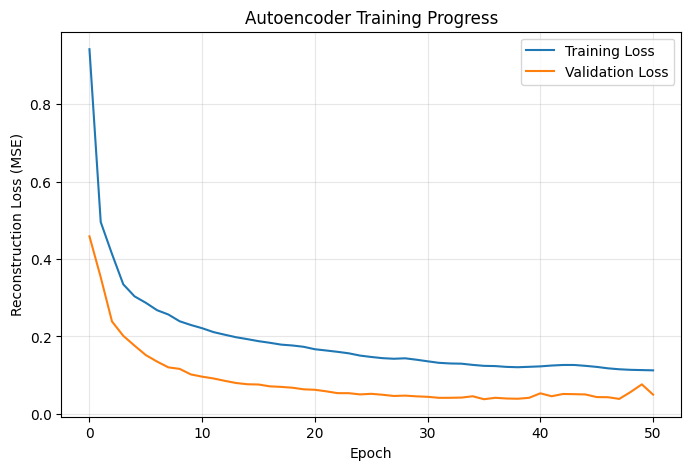

Final training loss:   0.1124
Final validation loss: 0.0496


In [5]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("Autoencoder Training Progress")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final training loss:   {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

**What to look for:** validation loss should decrease alongside training loss and roughly track it. If
validation loss is much higher than training loss (a growing gap), the autoencoder is overfitting — try
reducing epochs, adding dropout between encoder layers, or reducing to fewer than 300 input genes in the
previous notebook.

## 5. Evaluate Reconstruction Quality on Test Data
The test set was never seen during training. Reconstruction error here should be reasonably close to the
validation loss above — a big jump would suggest the autoencoder learned patterns specific to the training
data rather than genuinely general gene expression structure.

In [6]:
test_loss = autoencoder.evaluate(X_test, X_test, verbose=0)
print(f"Test reconstruction loss (MSE): {test_loss:.4f}")

Test reconstruction loss (MSE): 0.3491


## 6. Extract the 64-Dimensional Fingerprints
This is the actual output this stage exists to produce. Only the **Encoder** is used from here on — the
Decoder's job is done.

In [7]:
X_train_encoded = encoder.predict(X_train, verbose=0)
X_test_encoded = encoder.predict(X_test, verbose=0)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=[f"fingerprint_{i}" for i in range(X_train_encoded.shape[1])]
)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=[f"fingerprint_{i}" for i in range(X_test_encoded.shape[1])]
)

print("Encoded train shape:", X_train_encoded_df.shape)
print("Encoded test shape:", X_test_encoded_df.shape)
X_train_encoded_df.head()

Encoded train shape: (860, 64)
Encoded test shape: (117, 64)


,fingerprint_0,fingerprint_1,fingerprint_2,fingerprint_3,fingerprint_4,fingerprint_5,fingerprint_6,fingerprint_7,fingerprint_8,fingerprint_9,...,fingerprint_54,fingerprint_55,fingerprint_56,fingerprint_57,fingerprint_58,fingerprint_59,fingerprint_60,fingerprint_61,fingerprint_62,fingerprint_63
0,0.0,0.000000,6.373520,11.219459,0.0,0.645232,4.908454,0.000000,5.853534,0.0,...,7.237596,4.657844,1.909930,4.794473,0.0,2.391073,2.377610,0.0,0.000000,4.601715
1,0.0,0.000000,0.000000,0.000000,0.0,4.650407,0.357321,6.314835,0.000000,0.0,...,0.000000,0.000000,9.894368,0.000000,0.0,0.000000,3.164404,0.0,4.326508,0.000000
2,0.0,0.000000,2.265824,0.000000,0.0,0.000000,0.485377,0.455551,4.027449,0.0,...,1.136643,1.266468,5.032057,0.000000,0.0,0.691584,0.000000,0.0,0.476747,0.000000
3,0.0,0.220013,0.000000,2.402581,0.0,8.335362,0.706750,0.492189,0.000000,0.0,...,0.000000,0.000000,7.232464,0.000000,0.0,0.248296,3.504105,0.0,3.128172,0.000000
4,0.0,0.000000,8.785885,3.338109,0.0,0.000000,0.000000,0.000000,7.240326,0.0,...,2.271471,0.000000,0.059631,0.000000,0.0,2.693951,0.000000,0.0,0.000000,4.053056


## 7. Quick Sanity Check — Do Tumor and Normal Samples Separate at All?
Before handing this off to the CNN/XGBoost stage, a fast visual check: project the 64-dim fingerprint down
to 2D with PCA and see whether tumor and normal samples show any visible separation. This isn't a
rigorous test, but a completely random-looking mix here would be a warning sign worth investigating before
spending time training classifiers on top of it.

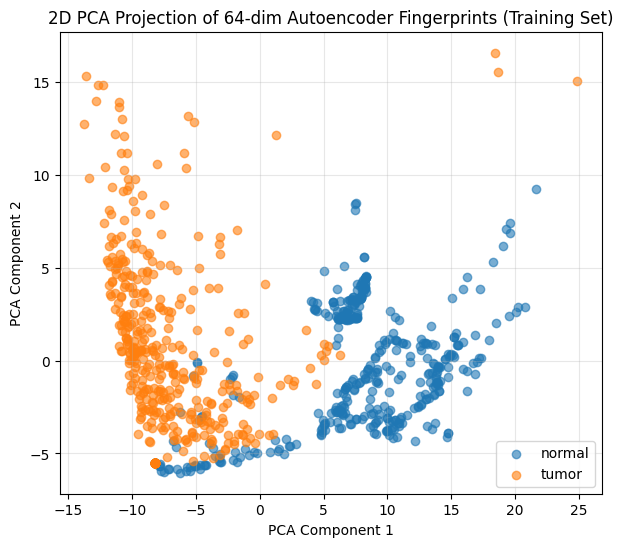

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
train_2d = pca.fit_transform(X_train_encoded)

plt.figure(figsize=(7, 6))
for label_value, label_name in label_mapping.items():
    mask = y_train == label_value
    plt.scatter(train_2d[mask, 0], train_2d[mask, 1], label=label_name, alpha=0.6)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D PCA Projection of 64-dim Autoencoder Fingerprints (Training Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Save Encoder Model and Encoded Features

In [9]:
# Save the trained encoder — this is what the backend /predict and /explain endpoints will load
# to turn a new patient's selected-gene input into a 64-dim fingerprint at inference time
encoder.save(f"{MODEL_DIR}/encoder_model.h5")

# Save the full autoencoder too, in case you want to report reconstruction quality later
autoencoder.save(f"{MODEL_DIR}/autoencoder_full.h5")

# Save the 64-dim fingerprints — these are what the CNN and XGBoost notebooks will train on
X_train_encoded_df.to_csv(f"{DATA_DIR}/X_train_encoded.csv", index=False)
X_test_encoded_df.to_csv(f"{DATA_DIR}/X_test_encoded.csv", index=False)

print("Saved encoder model to:", MODEL_DIR)
print(os.listdir(MODEL_DIR))
print("Saved encoded features to:", DATA_DIR)

Saved encoder model to: /content/drive/MyDrive/Gene Project/models
['encoder_model.h5', 'autoencoder_full.h5']
Saved encoded features to: /content/drive/MyDrive/Gene Project/processed_data
